In [7]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
import numpy as np

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [8]:
bidmc = fg.datasets.bidmc(
    subject=1,
)

In [9]:
bidmc = fg.oscillation.waves.add_wave_primitives(bidmc, ['respiration'])
bidmc = fg.oscillation.waves.add_wave_id(bidmc, ['respiration'], 'subject')
bidmc = fg.oscillation.waves.add_wave_features(bidmc, ['respiration'], 'respiration_wave_id')

In [10]:
bidmc['respiration_wave_id']

0          0
1          0
2          0
3          0
4          0
        ... 
59996    554
59997    554
59998    554
59999    554
60000    554
Name: respiration_wave_id, Length: 60001, dtype: int64

In [11]:
from featuregraph.utils.plot import plot

In [12]:
baseline = (
    bidmc.groupby('respiration_wave_id')['respiration']
         .transform('min')
)

bidmc['respiration_above_baseline'] = (
    bidmc['respiration'] - baseline
)

bidmc['auc_above_baseline'] = (
    bidmc.groupby('respiration_wave_id')
         ['respiration_above_baseline']
         .cumsum()
)

bidmc['auc_at_peak'] = np.where(bidmc['exit_respiration_rising'] == 1, bidmc['auc_above_baseline'], 0)

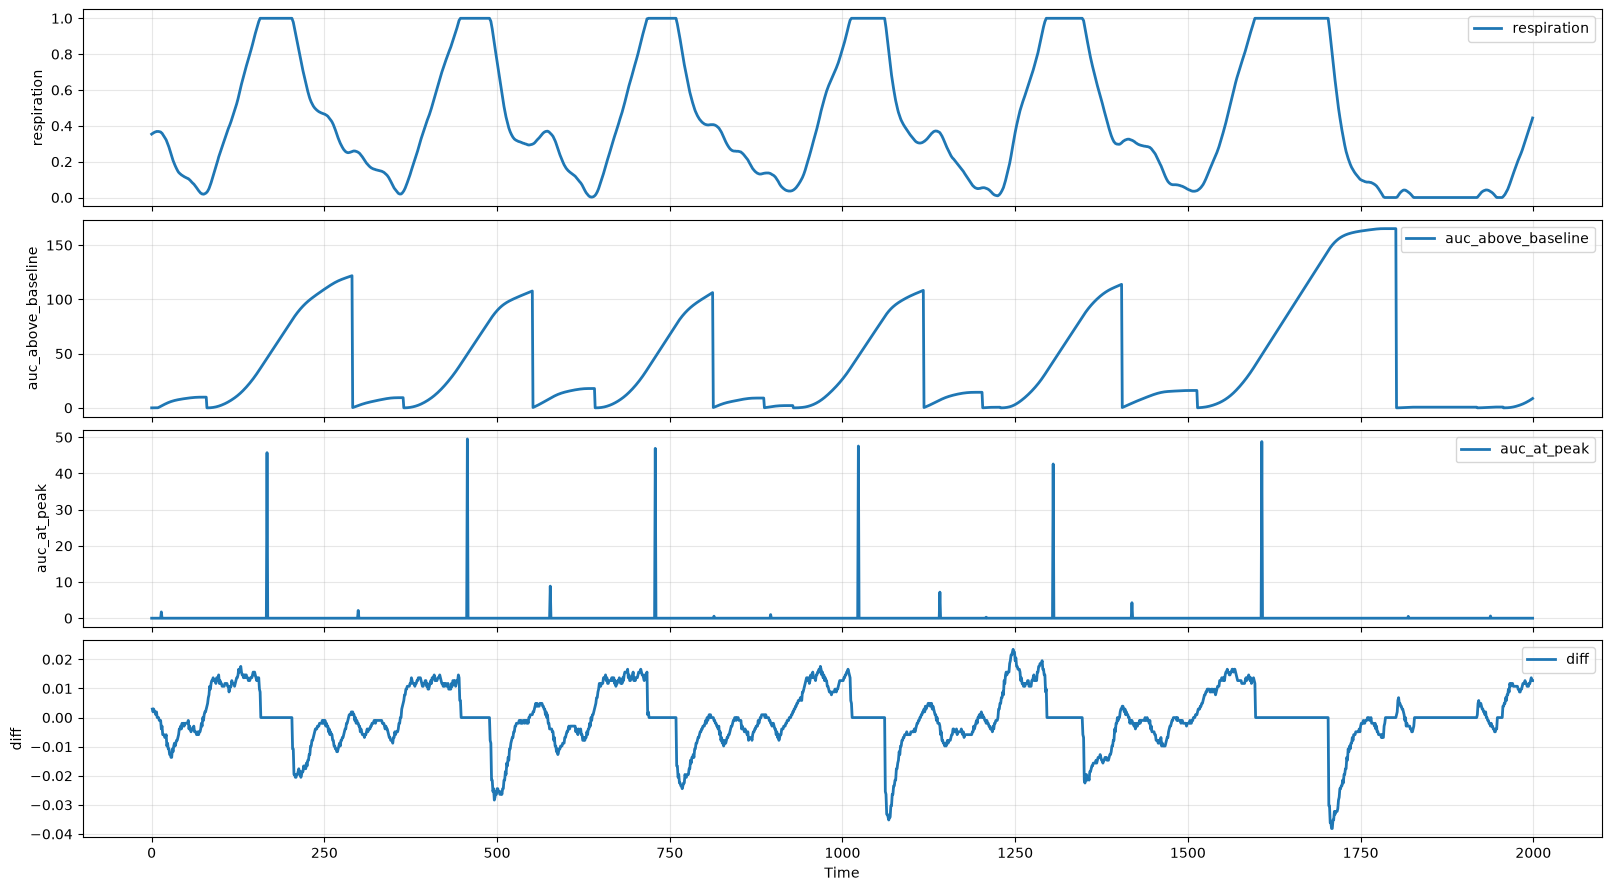

In [20]:
bidmc['diff'] = bidmc['respiration'].diff()
fig, axes = plot(bidmc[:2000],[['respiration'], ['auc_above_baseline'], ['auc_at_peak'], ['diff']])

In [ ]:
# time to max auc
# percentiles/quantiles

In [16]:
summarydf = bidmc.groupby('respiration_wave_id').agg(
    total_auc=('auc_above_baseline', 'max'),
    auc_mean=('auc_above_baseline', 'mean'),
    auc_at_peak=('auc_at_peak', 'max')
)

In [17]:
summarydf

,total_auc,auc_mean,auc_at_peak
respiration_wave_id,,,
0,0.093840,0.037636,0.000000
1,9.866038,7.233548,1.737045
2,121.809414,60.993803,45.742933
3,9.390079,6.333423,2.138800
4,107.700804,51.933221,49.525838
...,...,...,...
550,11.942353,7.854384,8.267878
551,3.753673,1.559279,2.547406
552,98.348120,46.223115,54.841690
